# Notebook 26 


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Q = 0.30
P = 1 - Q

AZUL = "#2563eb"
AMBAR = "#d97706"
VERDE = "#059669"
GRIS = "#64748b"
TINTA = "#172033"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

print(f"q = {Q:.2f} sana | p = {P:.2f} infectada")

q = 0.30 sana | p = 0.70 infectada


## 1. Los dos extremos: S0 y V

Para un pool fresco homogéneo de tamaño k:

$$
S_0(k)=q^k k.
$$

S0 pregunta cuánto se cobra **con esta prueba**. Solo paga si las k personas
están sanas, es decir, si r = 0.

El score de presupuesto mágico es:

$$
V(T)=\sum_{i\in T}u_i\,P(i\text{ sana}\mid h).
$$

V pregunta cuánto podría extraerse si todas las pruebas de seguimiento fueran
gratis. Para un pool fresco con utilidad unitaria, V(k)=qk.

Así aparecen los dos extremos

- S0 evita pools grandes.
- V prefiere pools grandes, aunque después no sepa cosecharlos.

In [2]:
ks = np.arange(1, 7)
tabla_scores = pd.DataFrame({
    "tamaño k": ks,
    "S0: cobro inmediato": (Q ** ks) * ks,
    "V: seguimiento gratis": Q * ks,
})

assert tabla_scores.loc[0, "S0: cobro inmediato"] == 0.3
assert abs(tabla_scores.loc[1, "S0: cobro inmediato"] - 0.18) < 1e-12
assert abs(tabla_scores.loc[1, "V: seguimiento gratis"] - 0.6) < 1e-12
tabla_scores

,tamaño k,S0: cobro inmediato,V: seguimiento gratis
0,1,0.300000,0.3
1,2,0.180000,0.6
2,3,0.081000,0.9
3,4,0.032400,1.2
4,5,0.012150,1.5
5,6,0.004374,1.8


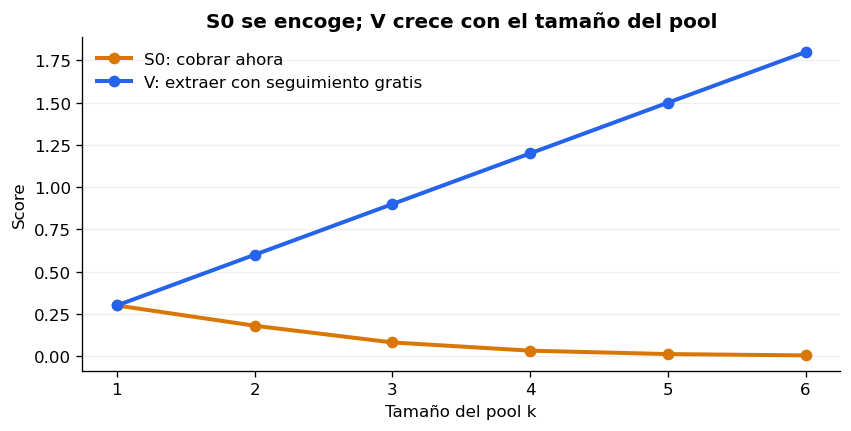

In [3]:
# FIGURA 1 DE 2
fig, ax = plt.subplots(figsize=(7.2, 3.7))
ax.plot(ks, tabla_scores["S0: cobro inmediato"], marker="o", lw=2.4,
        color=AMBAR, label="S0: cobrar ahora")
ax.plot(ks, tabla_scores["V: seguimiento gratis"], marker="o", lw=2.4,
        color=AZUL, label="V: extraer con seguimiento gratis")
ax.set_xlabel("Tamaño del pool k")
ax.set_ylabel("Score")
ax.set_xticks(ks)
ax.set_title("S0 se encoge; V crece con el tamaño del pool")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

S0 nunca da el primer paso grande en el régimen
q < 1/2. V sí da ese paso, pero lo hace porque "cree" que el trabajo posterior
es gratis.

## 5. El contraejemplo completo y la reparación

Estado: AB ya fue probado con r=1; C y D son vírgenes. Comparamos tres acciones:

- reentrar con A;
- abrir el par virgen CD;
- retestear AB.

V cuenta la utilidad sana localizada. C cuenta la prueba actual más el trabajo
posterior esperado.

In [4]:
acciones = pd.DataFrame({
    "acción": ["Reentrar A", "Par virgen CD", "Retest AB"],
    "V": [0.5, 0.6, 1.0],
    "C total": [1.0, 1.63, 2.5],
    "realizable con 1 prueba": [0.5, 0.18, 0.0],
})
acciones["V/C"] = acciones["V"] / acciones["C total"]

assert acciones.loc[acciones["V"].idxmax(), "acción"] == "Retest AB"
assert acciones.loc[acciones["V/C"].idxmax(), "acción"] == "Reentrar A"
assert acciones.loc[acciones["realizable con 1 prueba"].idxmax(), "acción"] == "Reentrar A"

acciones[["acción", "V", "C total", "V/C", "realizable con 1 prueba"]]

,acción,V,C total,V/C,realizable con 1 prueba
0,Reentrar A,0.5,1.00,0.500000,0.50
1,Par virgen CD,0.6,1.63,0.368098,0.18
2,Retest AB,1.0,2.50,0.400000,0.00


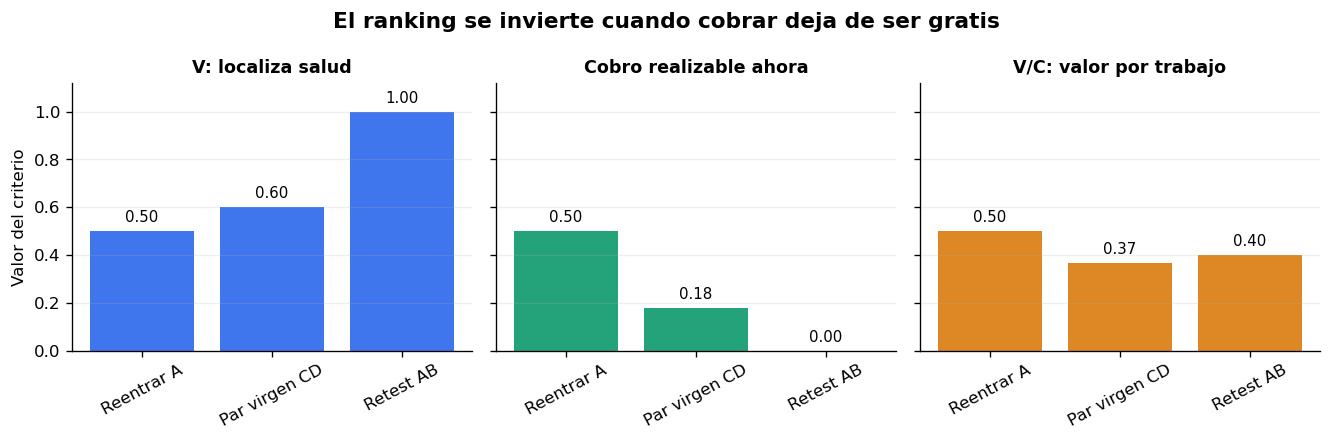

In [5]:
# FIGURA 2 DE 2
criterios = [
    ("V", "V: localiza salud", AZUL),
    ("realizable con 1 prueba", "Cobro realizable ahora", VERDE),
    ("V/C", "V/C: valor por trabajo", AMBAR),
]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.7), sharey=True)
for ax, (col, titulo, color) in zip(axes, criterios):
    vals = acciones[col].to_numpy()
    bars = ax.bar(acciones["acción"], vals, color=color, alpha=0.88)
    ax.set_title(titulo, fontsize=10.5)
    ax.tick_params(axis="x", rotation=28)
    ax.grid(axis="y", alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.025, f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("Valor del criterio")
axes[0].set_ylim(0, 1.12)
fig.suptitle("El ranking se invierte cuando cobrar deja de ser gratis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura de la figura 2.**

- V elige el retest porque ve una unidad sana atrapada en AB.
- El cobro realizable elige A porque es la única acción que puede acreditar
  esa utilidad con una prueba.
- V/C también elige A: penaliza el trabajo que V había fingido gratuito.



## Formulación


$$
\frac{V}{C^\alpha}.
$$

En el contraejemplo, el retest y la reentrada empatan cuando
$2.5^\alpha=2$, es decir, cuando
$\alpha=\ln 2/\ln 2.5\approx0.756$.

Con más experimentos vimos que ningún alpha domina en todos los
regímenes. Un alhpa grande ayuda cuando q es bajo, pero puede impedir agrupar
cuando q es alto. También importa si el costo se restringe a T o incluye otros
átomos abiertos.



## 7. El contraejemplo universal, visto como árbol

La sesión del 1-sep encargó buscar una instancia donde **todas** las
heurísticas greedy fallen a la vez. Existe: seis personas con probabilidades
de infección 0.8–0.95 y utilidades desiguales (E vale 4), B = 3, G = 4, bajo
posterior-zero (aquí la deducción **sí** acredita — es la convención nueva de
G0, distinta del hard clearing de las secciones anteriores). El inmediato, las
dos densidades del companion y C3 caen todas a **0.6576** del óptimo.

Dos vistas lo explican: el **menú** de la primera decisión (contra cuántas
alternativas ganó el óptimo y dónde quedaron las golosas) y el **árbol** de la
política óptima (qué hace el ganador, rama por rama).

optimo exacto 1.0645; mejor jugada AEF; las 6 peores jugadas del menu son los 6 singletons
ratio de las cuatro heuristicas: 0.6576 (scoreboard de la mision)


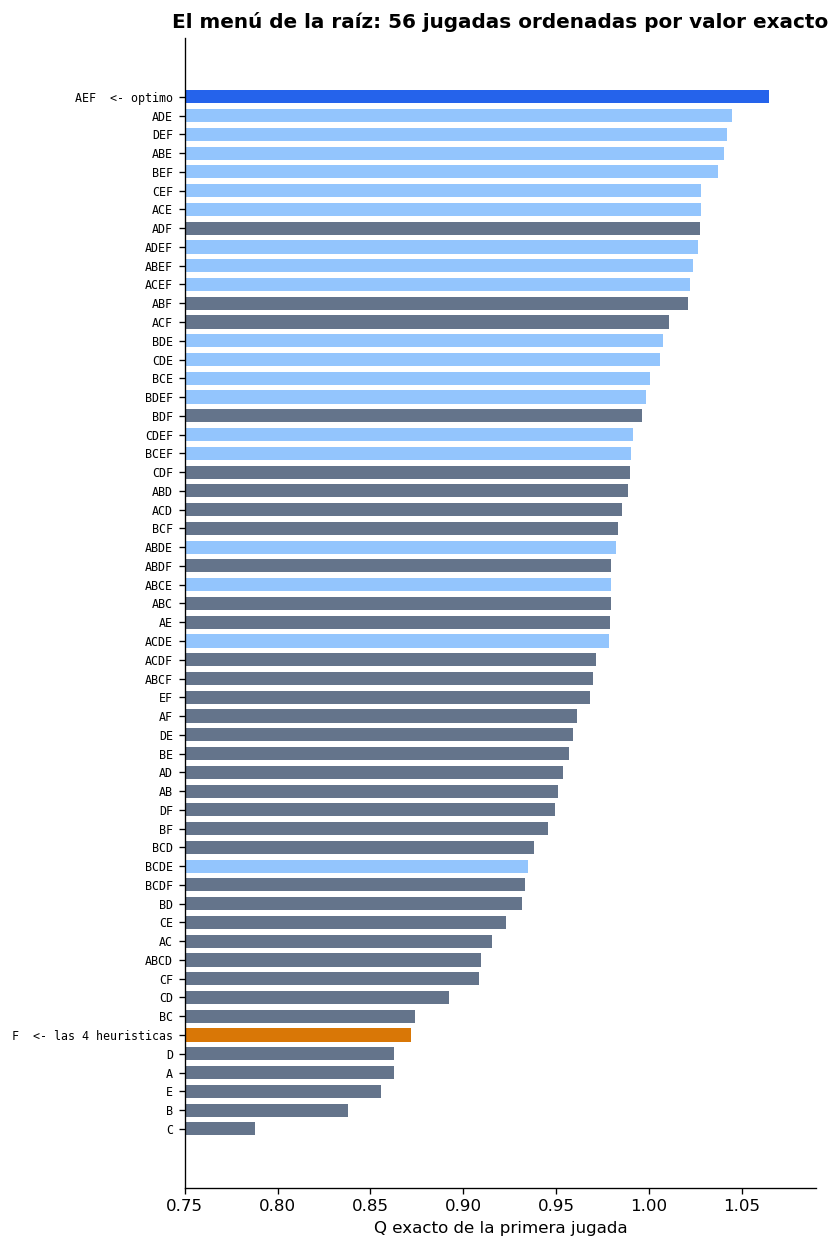

In [6]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
from fractions import Fraction
from augmented.bm17_toy_solver import SolverLaminar

p_ce = {0: Fraction('0.9'), 1: Fraction('0.825'), 2: Fraction('0.875'),
        3: Fraction('0.8'), 4: Fraction('0.95'), 5: Fraction('0.85')}
u_ce = {i: Fraction(v) for i, v in {0: 2, 1: 1, 2: 1, 3: 1, 4: 4, 5: 2}.items()}
sol = SolverLaminar(p_ce, u_ce, 4, 'posterior_zero')
U0 = frozenset(p_ce)
OPT = float(sol.V(U0, (), 3))
NOM = 'ABCDEF'

# el menu completo de la raiz: las 56 primeras jugadas con su Q exacto
menu = sorted(((float(sol._q_accion(U0, (), 3, a)),
                ''.join(NOM[i] for i in a[1]))
               for a in sol._acciones(U0, ())), reverse=True)

# Autoverificacion: optimo, la mejor jugada, y los singletons al fondo.
assert abs(OPT - 1.0645) < 5e-5 and menu[0][1] == 'AEF'
assert {s for _, s in menu[-6:]} == set('ABCDEF')
print(f'optimo exacto {OPT:.4f}; mejor jugada {menu[0][1]}; '
      f'las 6 peores jugadas del menu son los 6 singletons')
print(f'ratio de las cuatro heuristicas: 0.6576 (scoreboard de la mision)')

fig, ax = plt.subplots(figsize=(7.0, 10.5))
colores, etiquetas = [], []
for q_, s in menu:
    if s == 'AEF':
        colores.append(AZUL); etiquetas.append(f'{s}  <- optimo')
    elif s == 'F':
        colores.append(AMBAR); etiquetas.append(f'{s}  <- las 4 heuristicas')
    else:
        colores.append('#93c5fd' if ('E' in s and len(s) >= 3) else GRIS)
        etiquetas.append(s)
ax.barh(range(len(menu)), [q_ for q_, _ in menu], color=colores, height=0.7)
ax.set_yticks(range(len(menu)))
ax.set_yticklabels(etiquetas, fontsize=7, fontfamily='monospace')
ax.invert_yaxis(); ax.set_xlim(0.75, 1.09)
ax.set_xlabel('Q exacto de la primera jugada')
ax.set_title('El menú de la raíz: 56 jugadas ordenadas por valor exacto')
plt.tight_layout(); plt.show()

**Lectura del menú.** Todo el tercio superior son pools de 3+ que contienen a
E (la persona de u = 4); los seis singletons son las seis peores jugadas, y la
elección de las heurísticas (F sola) ocupa el lugar 51 de 56. El error de las
golosas no es de afinación sino de categoría: cobrar en vez de explorar.

el arbol de la POLITICA optima: 35 nodos — extraido de un problema con 1786 estados distintos (el arbol completo sin compartir tendria ~116 mil nodos)


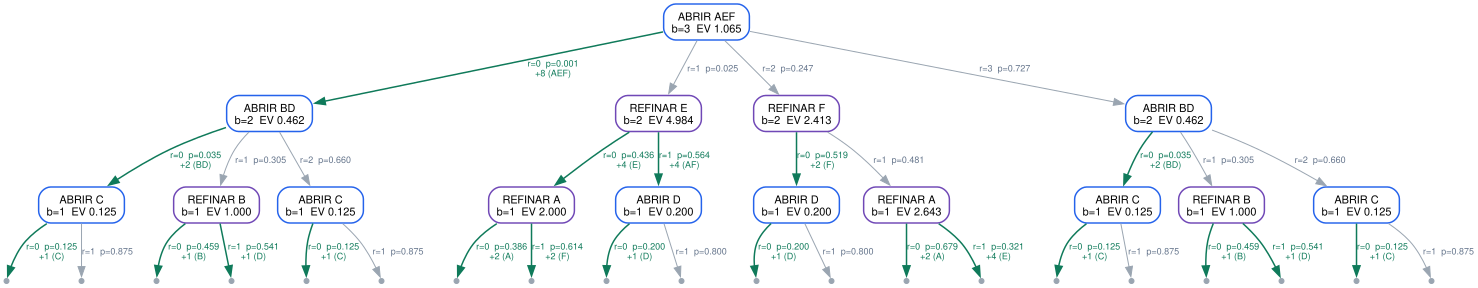

In [7]:
import graphviz

g = graphviz.Digraph(format='svg')
g.attr(rankdir='TB', fontname='Helvetica')
g.attr('node', fontname='Helvetica', fontsize='11')
g.attr('edge', fontname='Helvetica', fontsize='9')
cont = [0]

def dibuja(U, atomos, b):
    U, atomos = sol._canoniza(U, atomos)
    v = float(sol.V(U, atomos, b))
    acc = sol.argmax.get((U, atomos, b))
    yo = f'n{cont[0]}'; cont[0] += 1
    if acc is None or b == 0:
        g.node(yo, '', shape='point', width='0.07', color='#9aa5b1')
        return yo
    verbo = 'ABRIR' if acc[0] == 'open' else 'REFINAR'
    pool = acc[1] if acc[0] == 'open' else acc[2]
    etq = f"{verbo} {''.join(NOM[i] for i in pool)}\nb={b}  EV {v:.3f}"
    g.node(yo, etq, shape='box', style='rounded',
           color=AZUL if verbo == 'ABRIR' else '#7048b6', penwidth='1.5')
    if acc[0] == 'open':
        S = acc[1]; zs = sol._z(S)
        ramas = []
        for s_, prob in enumerate(zs):
            if prob == 0: continue
            rew, nuevos = sol._pieza(S, s_, probado=True)
            ramas.append((s_, float(prob), float(rew),
                          ''.join(NOM[i] for i in S) if s_ == 0 else '',
                          (U - set(S), tuple(sorted(atomos + nuevos)))))
    else:
        _, (A, r), S = acc
        resto = tuple(sorted(set(A) - set(S)))
        zS, zR, zA = sol._z(S), sol._z(resto), sol._z(A)
        otros = tuple(a for a in atomos if a != (A, r))
        ramas = []
        for s_ in range(len(zS)):
            if not (0 <= r - s_ < len(zR)): continue
            prob = zS[s_] * zR[r - s_] / zA[r]
            if prob == 0: continue
            rS, nS = sol._pieza(S, s_, probado=True)
            rR, nR = sol._pieza(resto, r - s_, probado=False)
            acred = (''.join(NOM[i] for i in S) if s_ == 0 else '') + \
                    (''.join(NOM[i] for i in resto) if r - s_ == 0 else '')
            ramas.append((s_, float(prob), float(rS + rR), acred,
                          (U, tuple(sorted(otros + nS + nR)))))
    for s_, prob, rew, acred, (U2, at2) in ramas:
        hijo = dibuja(U2, at2, b - 1)
        etqr = f'r={s_}  p={prob:.3f}'
        if rew > 0:
            g.edge(yo, hijo, label=etqr + f'\n+{rew:.0f} ({acred})',
                   color='#0f7a5a', fontcolor='#0f7a5a', penwidth='1.5')
        else:
            g.edge(yo, hijo, label=etqr, color='#9aa5b1', fontcolor=GRIS)
    return yo

dibuja(U0, (), 3)
print(f'el arbol de la POLITICA optima: {cont[0]} nodos — extraido de un '
      f'problema con {len(sol.memo)} estados distintos '
      f'(el arbol completo sin compartir tendria ~116 mil nodos)')
g

**Lectura del árbol.** El óptimo abre el trío AEF aunque casi nunca sale
limpio (p = 0.001): lo abre porque cada conteo compra una continuación
distinta. La joya son los refinamientos de **doble filo**: tras conteo 1,
probar a E cobra 4 salga lo que salga — si E está sana cobra sus 4, y si está
infectada la deducción acredita a A y F (2+2). Eso — repartir presupuesto
según el conteo y cosechar por deducción — es lo que ningún score de un paso
ve, y por eso las cuatro heurísticas caen a 0.6576. La frase de Vlad aplica
invertida: aquí, **lo cobrable ni siquiera parece valioso** hasta que el
conteo llega.